In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df['director']=df['director'].fillna('Unknown')

df['cast']=df['cast'].fillna('Unknown')

df['country']=df['country'].fillna('Unknown')

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df['date_added'] = df['date_added'].str.strip()

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'])

In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


EDA Question 1:
What type of content dominates Netflix?

Observation:
Movies dominate the Netflix catalog with 6126 titles compared to 2664 TV Shows.

Insight:
Netflix appears to focus more heavily on movie production and acquisition than TV content.

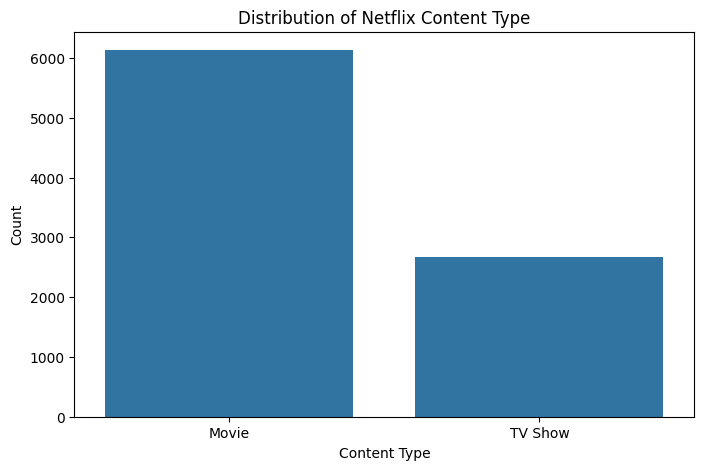

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='type',
    data=df
)

plt.title("Distribution of Netflix Content Type")

plt.xlabel("Content Type")

plt.ylabel("Count")

plt.show()

In [ ]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


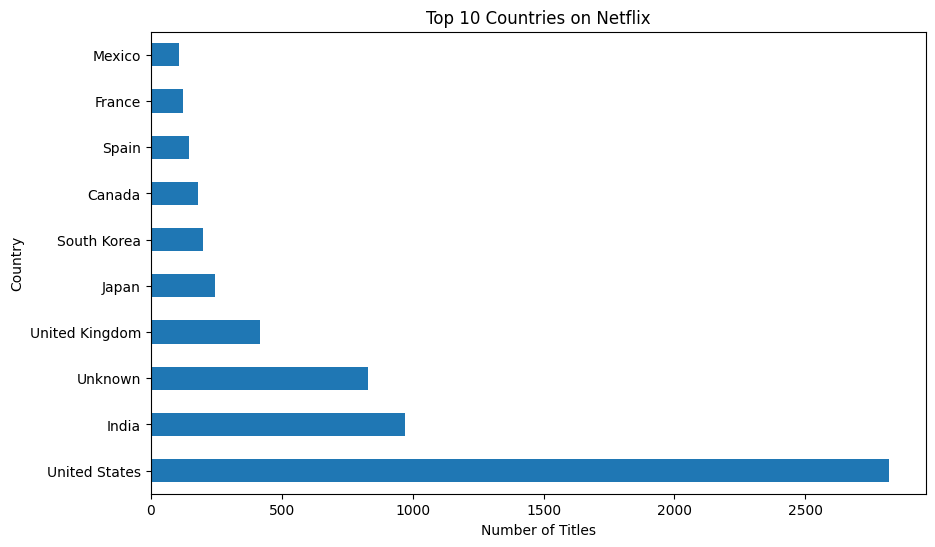

In [ ]:
top_country = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_country.plot(
    kind='barh'
)

plt.title(
"Top 10 Countries on Netflix"
)

plt.xlabel(
"Number of Titles"
)

plt.ylabel(
"Country"
)

plt.show()

EDA Question 2: Which countries contribute the most Netflix content?

Observation: The United States contributes the highest number of titles followed by India.

Insight: Netflix has stronger content availability in the US market, while India is an important secondary market.

In [ ]:
df['release_year'].value_counts().head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


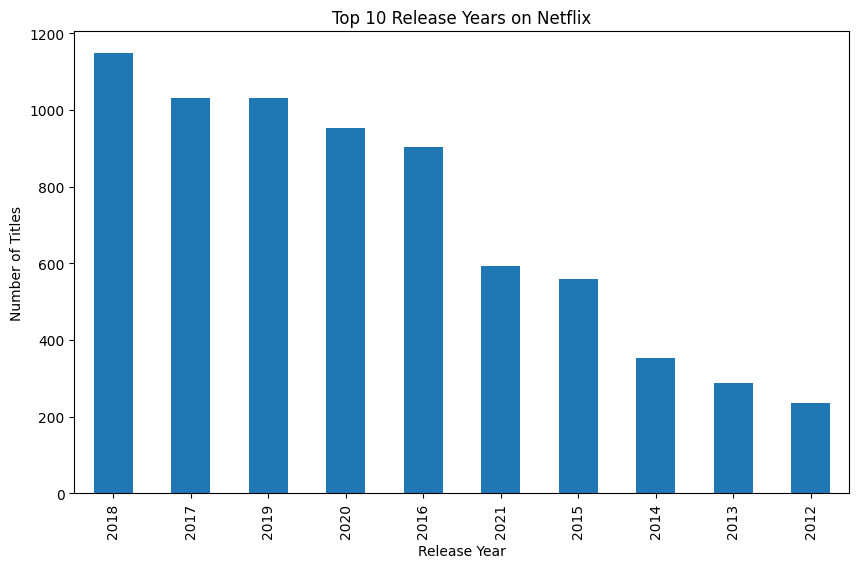

In [ ]:
top_year=df['release_year'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_year.plot(
    kind='bar'
)

plt.title(
"Top 10 Release Years on Netflix"
)

plt.xlabel(
"Release Year"
)

plt.ylabel(
"Number of Titles"
)

plt.show()

EDA Question 3:
Which release years dominate Netflix content?

Observation:
Most Netflix titles belong to the release years 2016–2020, with 2018 having the highest count.

Insight:
Netflix appears to contain more recent content, suggesting emphasis on relatively modern productions.

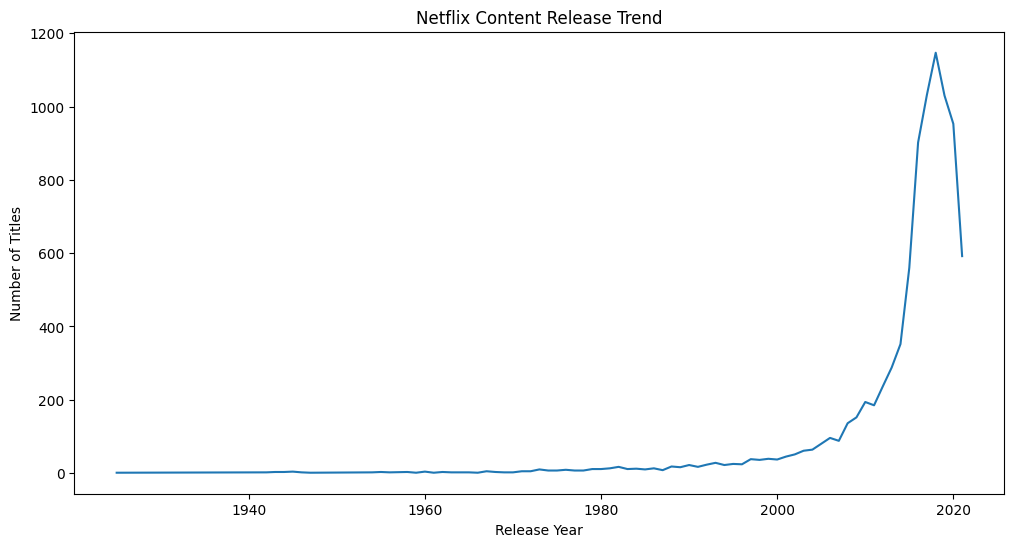

In [ ]:
year_count = (
df['release_year']
.value_counts()
.sort_index()
)

plt.figure(figsize=(12,6))

plt.plot(
year_count.index,
year_count.values
)

plt.title(
"Netflix Content Release Trend"
)

plt.xlabel(
"Release Year"
)

plt.ylabel(
"Number of Titles"
)

plt.show()

Visualization Insight:

The line chart shows a gradual increase in content releases over time followed by a sudden peak around 2018. This suggests that Netflix's catalog contains a large amount of modern content.

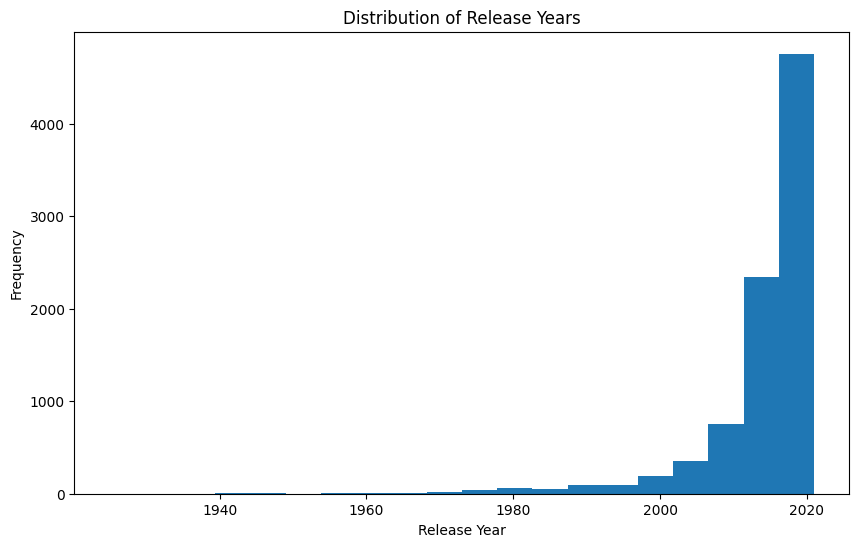

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
df['release_year'],
bins=20
)

plt.title(
"Distribution of Release Years"
)

plt.xlabel(
"Release Year"
)

plt.ylabel(
"Frequency"
)

plt.show()

Visualization Insight:

The histogram is right-skewed toward recent years, indicating that Netflix contains a larger amount of modern content compared to older releases.

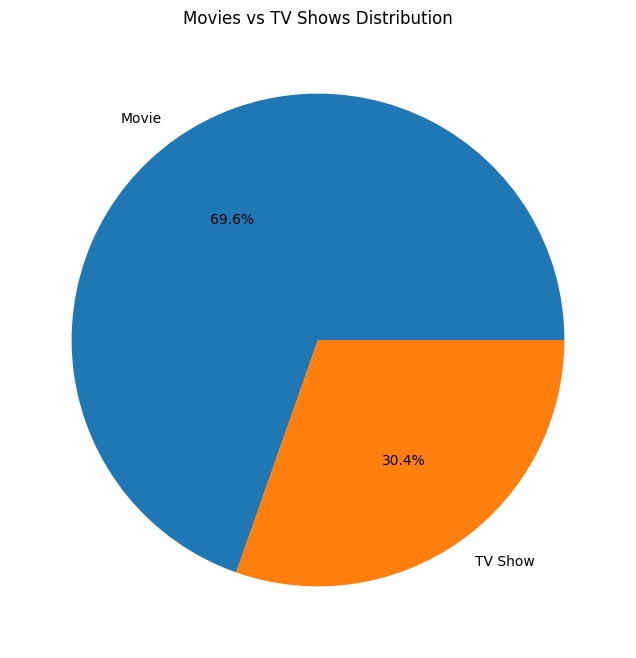

In [ ]:
type_count = df['type'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
type_count,
labels=type_count.index,
autopct='%1.1f%%'
)

plt.title(
"Movies vs TV Shows Distribution"
)

plt.show()

Visualization Insight:

Movies occupy approximately 69.6% of Netflix content while TV Shows account for 30.4%. This indicates Netflix places stronger emphasis on movie content.

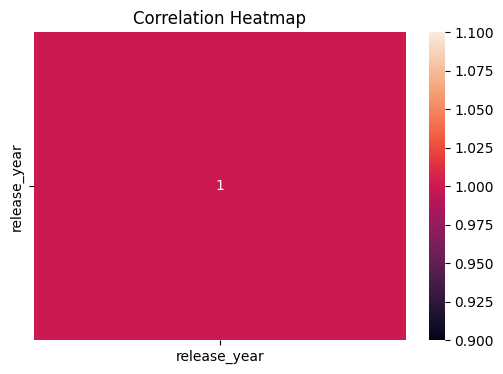

In [ ]:
corr=df[['release_year']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
corr,
annot=True
)

plt.title(
"Correlation Heatmap"
)

plt.show()

Visualization Insight:

The initial heatmap showed a perfect correlation because a variable was compared with itself. A more useful heatmap compares release year with year added to understand relationships between variables.

# Final Insights Report

## Insight 1

Movies dominate Netflix content, representing approximately 69.6% of the total catalog while TV Shows contribute 30.4%.

## Insight 2

The United States contributes the highest number of Netflix titles, followed by India, indicating strong content concentration in these regions.

## Insight 3

Most available Netflix content belongs to recent release years, especially between 2016 and 2020, showing emphasis on modern entertainment.

## Insight 4

The release trend showed a noticeable peak around 2018, indicating a large amount of content from that period.

## Insight 5

The distribution of release years is concentrated toward recent years, suggesting Netflix prioritizes newer content over older releases.
